In [27]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
data = pd.read_csv("/Users/judet/Downloads/Code with Python/My Projects/PROJECT 23 - RESEARCH ANALYSIS/Home_Workout_Data.csv", delimiter=",")

In [3]:
print(data.columns)

Index(['Age Range', 'Gender', 'Level of Education',
       'Approximate Annual Income Range in Euros (€)', 'Residence',
       'Approximate Distance to the Nearest Gym', '1st Important Factor',
       '2nd Important Factor', '3rd Important Factor', '4th Important Factor',
       '5th Important Factor', 'Frequency of Workouts at Home',
       'Equipments Owned\n', 'Main Challenges', 'Solutions Found',
       'Transitioning to a Gym',
       'Factors That Influenced transitioning to a gym', 'Seeked Supports'],
      dtype='object')


## What is the distribution of education levels among the respondents?

Level of Education
Bachelor's degree                      62
High School or below                   17
Some college or vocational training    11
Master's degree                         5
Doctorate or other advanced degree      3
Name: count, dtype: int64


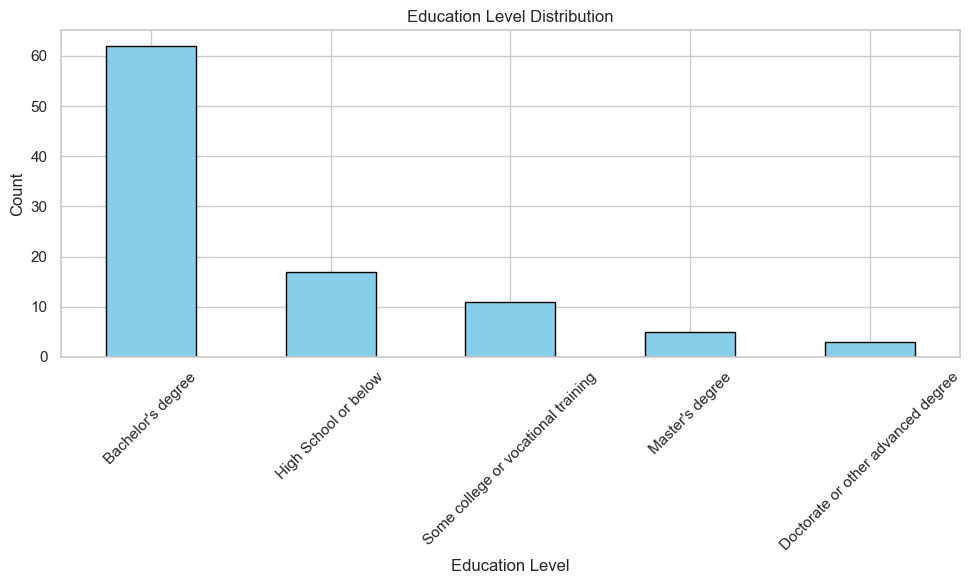

In [16]:
# Get the data
education_counts = data["Level of Education"].value_counts()
print(education_counts)

# Plot the bar chart
education_counts.plot(kind='bar', figsize=(10, 6), color='skyblue', edgecolor='black')

# Set the labels and title
plt.title("Education Level Distribution")
plt.xlabel("Education Level")
plt.ylabel("Count")

# Rotate x-axis labels and adjust layout
plt.xticks(rotation=45)
plt.tight_layout()

plt.show()

## What is the frequency distribution of respondent ages?

Age Range
18-24       78
25-34        6
35-44        2
45-54        4
55-64        2
Under 18     6
Name: count, dtype: int64


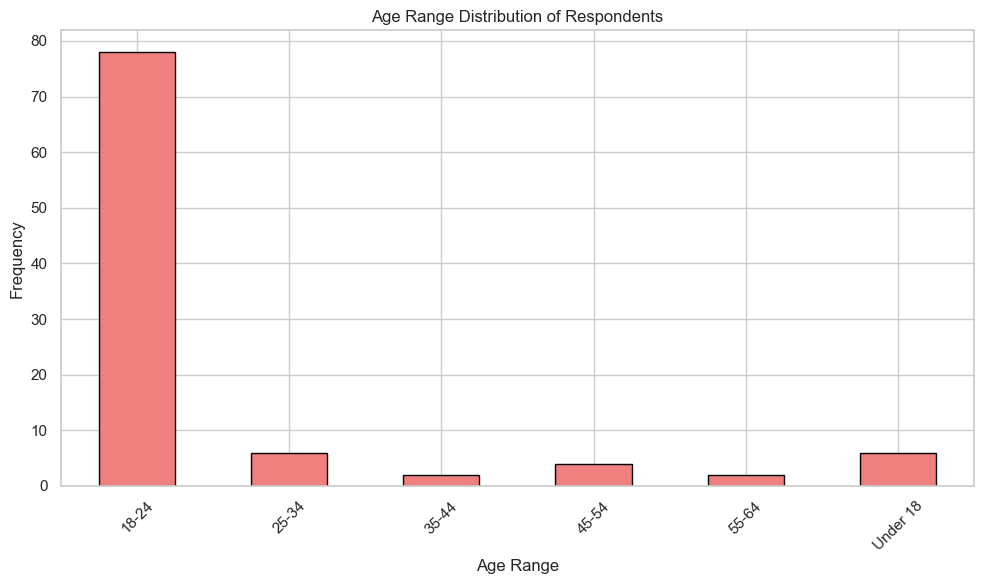

In [17]:
# Count the frequency of each age range
age_counts = data["Age Range"].value_counts().sort_index()  # sort_index() keeps the ranges in order if they're well-formatted
print(age_counts)

# Plot bar chart
age_counts.plot(kind='bar', figsize=(10, 6), color='lightcoral', edgecolor='black')

# Add labels and title
plt.title("Age Range Distribution of Respondents")
plt.xlabel("Age Range")
plt.ylabel("Frequency")

# Rotate x-axis labels for clarity
plt.xticks(rotation=45)
plt.tight_layout()

# Show the plot
plt.show()

## How does the proximity to the nearest gym vary across different age groups and types of residence?

Approximate Distance to the Nearest Gym  1-2 miles (≈ 1.6-3.2 km)  \
Age Range Residence                                                 
18-24     Rural                                               0.0   
          Urban                                               7.0   
25-34     Rural                                               0.0   
          Urban                                               1.0   
35-44     Urban                                               0.0   
45-54     Rural                                               1.0   
          Urban                                               0.0   
55-64     Urban                                               1.0   
Under 18  Urban                                               0.0   

Approximate Distance to the Nearest Gym  2-5 miles (≈ 3.2-8 km)  \
Age Range Residence                                               
18-24     Rural                                             0.0   
          Urban                        

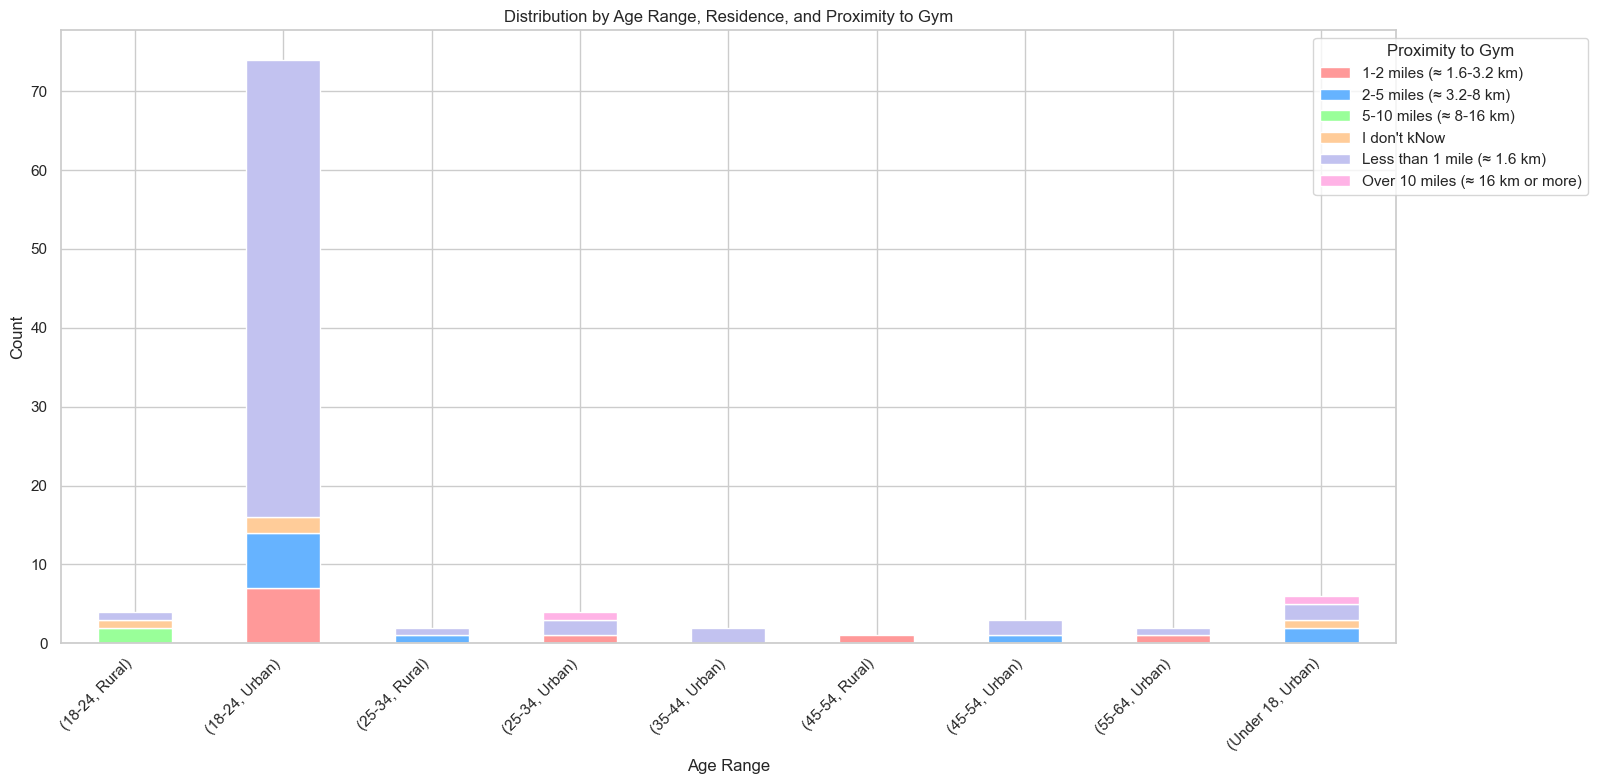

In [18]:
grouped_data = data.groupby(['Age Range', 'Residence', 'Approximate Distance to the Nearest Gym'])['Age Range'].count().unstack().fillna(0)
print(grouped_data)

colors = ['#ff9999', '#66b3ff', '#99ff99', '#ffcc99', '#c2c2f0', '#ffb3e6']
ax = grouped_data.plot(kind='bar', stacked=True, color=colors, figsize=(16, 8))

plt.title('Distribution by Age Range, Residence, and Proximity to Gym')
plt.xlabel('Age Range')
plt.ylabel('Count')
plt.xticks(rotation=45, ha='right')

ax.legend(title='Proximity to Gym', loc='upper right', bbox_to_anchor=(1.15, 1))

plt.tight_layout()
plt.show()

## Which factors are prioritized most across different importance levels?

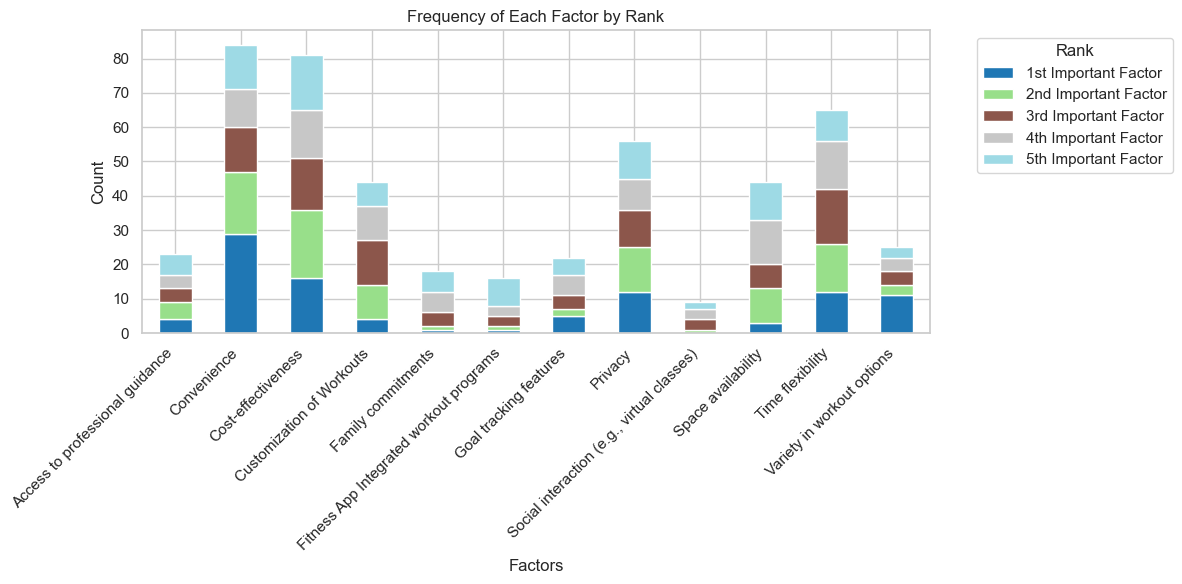

In [19]:
factors = data[['1st Important Factor', 
                '2nd Important Factor', 
                '3rd Important Factor', 
                '4th Important Factor', 
                '5th Important Factor']]

# Count how often each factor appears in each column
factor_counts = factors.apply(pd.Series.value_counts).fillna(0)

# Plot as stacked bar chart (each rank is a separate color)
factor_counts.plot(kind='bar', stacked=True, figsize=(12, 6), 
                   colormap='tab20')

# Chart formatting
plt.title('Frequency of Each Factor by Rank')
plt.xlabel('Factors')
plt.ylabel('Count')

plt.legend(title='Rank', bbox_to_anchor=(1.05, 1), loc='upper left')

plt.xticks(rotation=45, ha='right')
plt.tight_layout()

plt.show()

Here we can see that across all rank, "Convenience" has been chosen with the most count with "Cost-effectiveness" following closely behind.

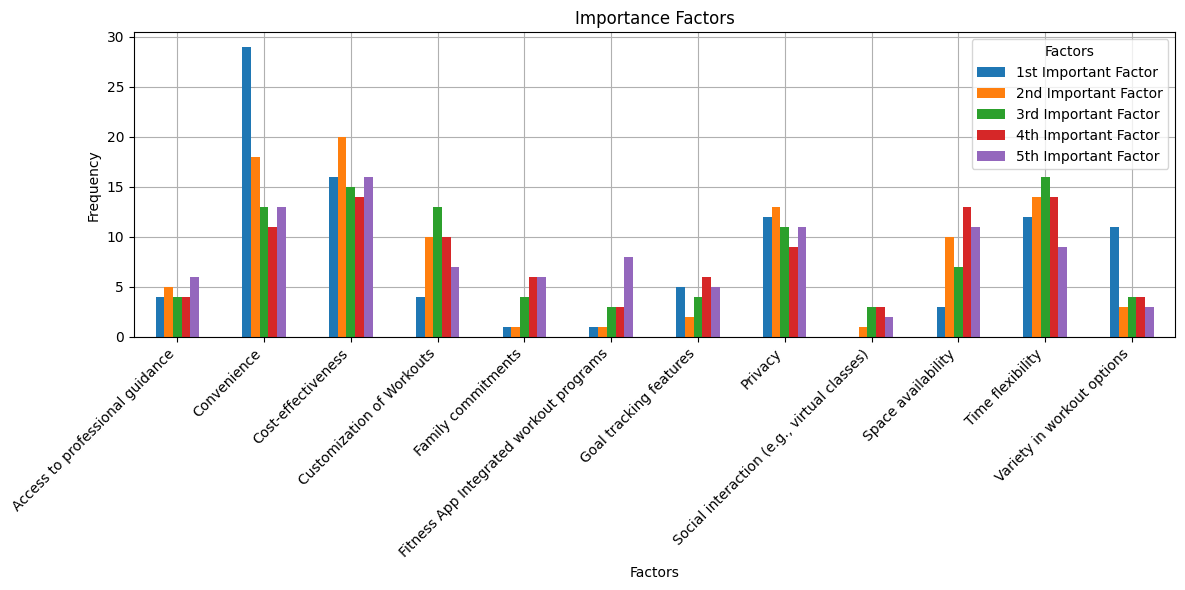

In [8]:
factors = data[['1st Important Factor', '2nd Important Factor', '3rd Important Factor', '4th Important Factor', '5th Important Factor']]

# Count occurrences of each factor in each column
factor_counts = factors.apply(pd.Series.value_counts)

# Plot and capture the Axes
ax = factor_counts.plot(kind='bar', figsize=(12, 6))

# Set axis below so grid is behind the bars
ax.set_axisbelow(True)
ax.grid(True, axis='both')

# Add titles and labels
ax.set_title('Importance Factors')
ax.set_xlabel('Factors')
ax.set_ylabel('Frequency')

# Ticks and legend
ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha='right')
ax.legend(title='Factors')

plt.tight_layout()
plt.show()


## Which factors has the highest score across all ranks? Assign scores to each factor based on its importance (1st +5...2nd +4 etc)

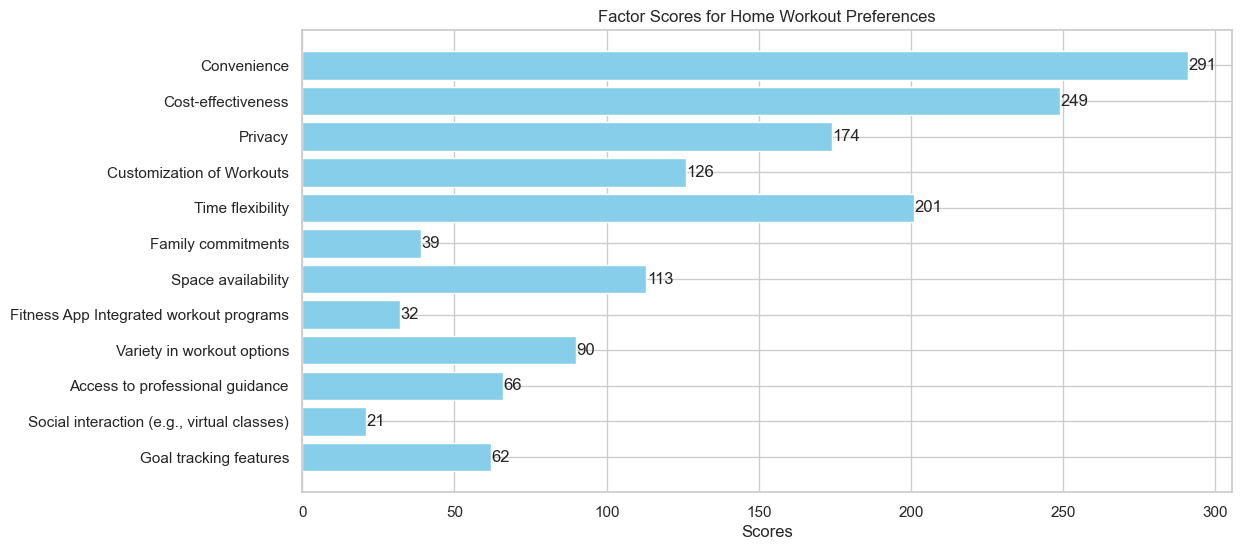

In [20]:
factor_scores = {
    "Convenience": 0,
    "Cost-effectiveness": 0,
    "Privacy": 0,
    "Customization of Workouts": 0,
    "Time flexibility": 0,
    "Family commitments": 0,
    "Space availability": 0,
    "Fitness App Integrated workout programs": 0,
    "Variety in workout options": 0,
    "Access to professional guidance": 0,
    "Social interaction (e.g., virtual classes)": 0,
    "Goal tracking features": 0,
}

ranks = ["1st Important Factor", "2nd Important Factor", "3rd Important Factor", "4th Important Factor", "5th Important Factor"]

for rank in ranks:
    rank_index = int(rank[0]) # Extract the index (1, 2, 3, 4, 5)

    for factor in data[rank]:
        if factor in factor_scores:
            factor_scores[factor] += 6 - rank_index

factors = list(factor_scores.keys())
scores = list(factor_scores.values())

plt.figure(figsize=(12, 6))
plt.barh(factors, scores, color='skyblue')

plt.xlabel('Scores')
plt.title('Factor Scores for Home Workout Preferences')
plt.gca().invert_yaxis()  # Invert the y-axis for better readability

for i, score in enumerate(scores):
    plt.text(score + 0.2, i, str(score), va='center', fontsize=12)

plt.show()

In [10]:
print(data["Equipments Owned\n"])

0     Dumbbells, Resistance bands, Yoga/Fitness mat,...
1                                           Parallettes
2                     Yoga/Fitness mat, Stationary bike
3                                      Yoga/Fitness mat
4                                      Yoga/Fitness mat
                            ...                        
93                                                  NaN
94    Dumbbells, Treadmill, Stationary bike, Bodywei...
95                          Dumbbells, Yoga/Fitness mat
96    Dumbbells, Resistance bands, Yoga/Fitness mat,...
97        Dumbbells, Resistance bands, Yoga/Fitness mat
Name: Equipments Owned\n, Length: 98, dtype: object


## What types of fitness equipment are most commonly owned by respondents?

                   Equipment  Count
2           Yoga/Fitness mat     52
0                  Dumbbells     38
1           Resistance bands     34
3                  Treadmill     18
5  Bodyweight exercises only     15
4            Stationary bike     13
6                Parallettes      4
7                       None      2


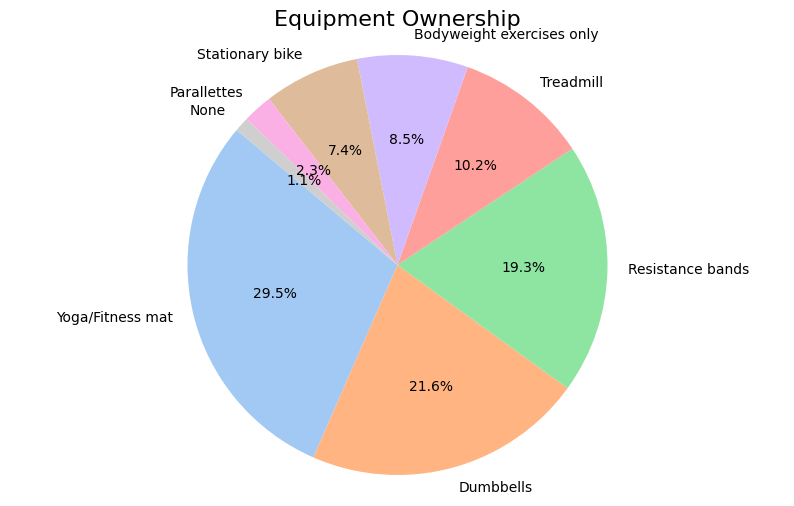

In [11]:
equipment_counts = {
    'Dumbbells': 0,
    'Resistance bands': 0,
    'Yoga/Fitness mat': 0,
    'Treadmill': 0,
    'Stationary bike': 0,
    'Bodyweight exercises only': 0,
    'Parallettes': 0,
    'None': 0
}

for row in data['Equipments Owned\n']:
    if pd.notna(row): 
        equipment_list = [equipment.strip() for equipment in row.split(',')]

        for equipment in equipment_list:
            if equipment in equipment_counts:
                equipment_counts[equipment] += 1

equipment_df = pd.DataFrame(list(equipment_counts.items()), columns=['Equipment', 'Count'])
equipment_df = equipment_df.sort_values(by='Count', ascending=False)
print(equipment_df)

colors = sb.color_palette("pastel")[0:len(equipment_df)]

# Pie chart
plt.figure(figsize=(10, 6))
plt.pie(equipment_df['Count'], labels=equipment_df['Equipment'], autopct='%1.1f%%', startangle=140, colors=colors)
plt.title('Equipment Ownership', fontsize=16)

plt.axis('equal')

plt.show()

## What are the main challenges people face in maintaining their fitness routine?

In [12]:
print(data["Main Challenges"])      

0     Lack of motivation, Limited space, Difficulty ...
1                                    Lack of motivation
2     Lack of motivation, Difficulty in staying cons...
3     Lack of motivation, Difficulty in staying cons...
4     Lack of motivation, Limited space, Lack of pro...
                            ...                        
93                                   Lack of motivation
94    Lack of motivation, Difficulty in staying cons...
95    Lack of motivation, Limited space, Lack of pro...
96    Lack of motivation, Difficulty in staying cons...
97                                   Lack of motivation
Name: Main Challenges, Length: 98, dtype: object


                                          Challenges  Count
0                                 Lack of motivation     56
1                                      Limited space     49
2                   Difficulty in staying consistent     51
3       Lack of proper guidance or training programs     35
4                         Boredom with home workouts     33
5                   Physical limitations or injuries      9
6                         Noise/distractions at home     11
7                                       Limited time      1
8                                                         4
9  Very limited gym times (11 to 4) that do Not f...      1


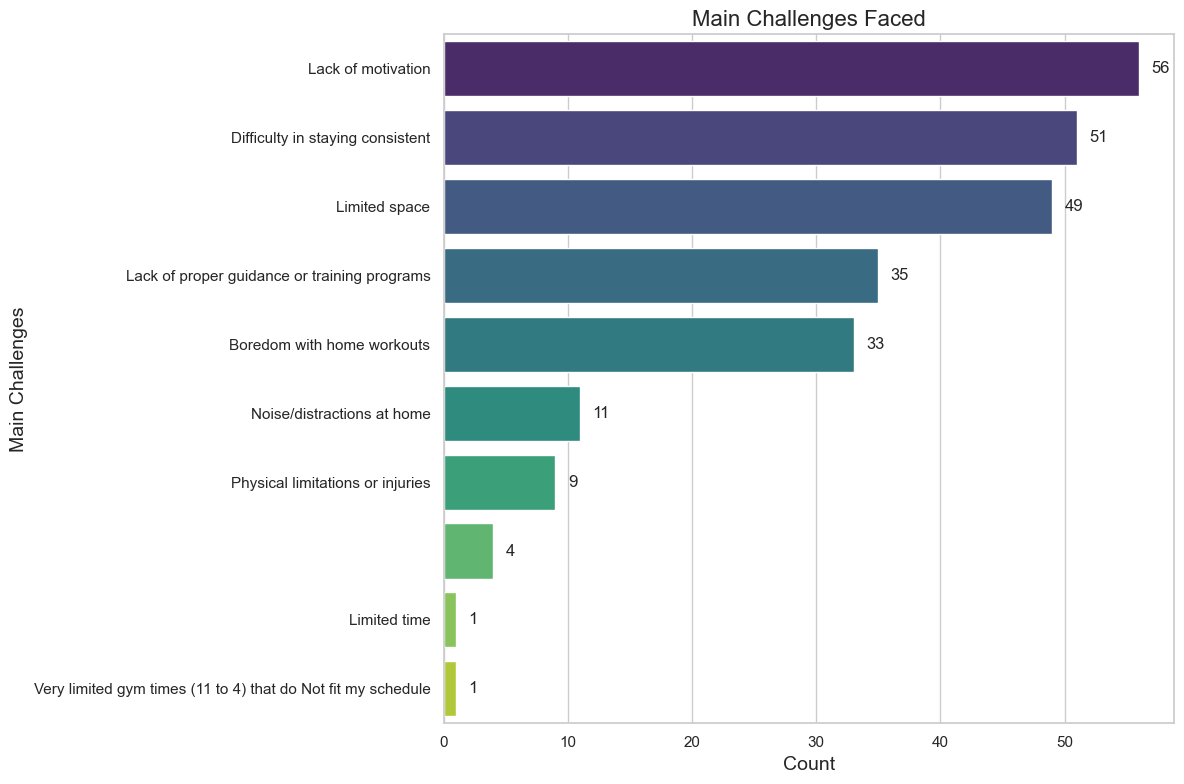

In [53]:
challenge_counts = {}

for row in data["Main Challenges"]:
    if pd.notna(row):
        challenge_list = [challenge.strip() for challenge in row.split(',')]

        for challenge in challenge_list:
            if challenge in challenge_counts:
                challenge_counts[challenge] += 1
            else:
                challenge_counts[challenge] = 1

challenge_df = pd.DataFrame(list(challenge_counts.items()), columns=["Challenges", "Count"])
print(challenge_df)

challenge_df = challenge_df.sort_values(by="Count", ascending=False)

plt.figure(figsize=(12, 8))
sns.set(style="whitegrid")
ax = sns.barplot(x="Count", y="Challenges", data=challenge_df, hue="Challenges", palette="viridis", legend=False)

ax.set_xlabel("Count", fontsize=14)
ax.set_ylabel("Main Challenges", fontsize=14)
ax.set_title("Main Challenges Faced", fontsize=16)

for p in ax.patches:
    ax.annotate(f"{int(p.get_width())}", (p.get_width() + 1, p.get_y() + p.get_height() / 2), ha="left", va="center", fontsize=12)

plt.tight_layout()
plt.show()

## Does residence affect the intention to transition to a gym?

Transitioning to a Gym  No  Yes
Residence                      
Rural                    2    5
Urban                   18   72


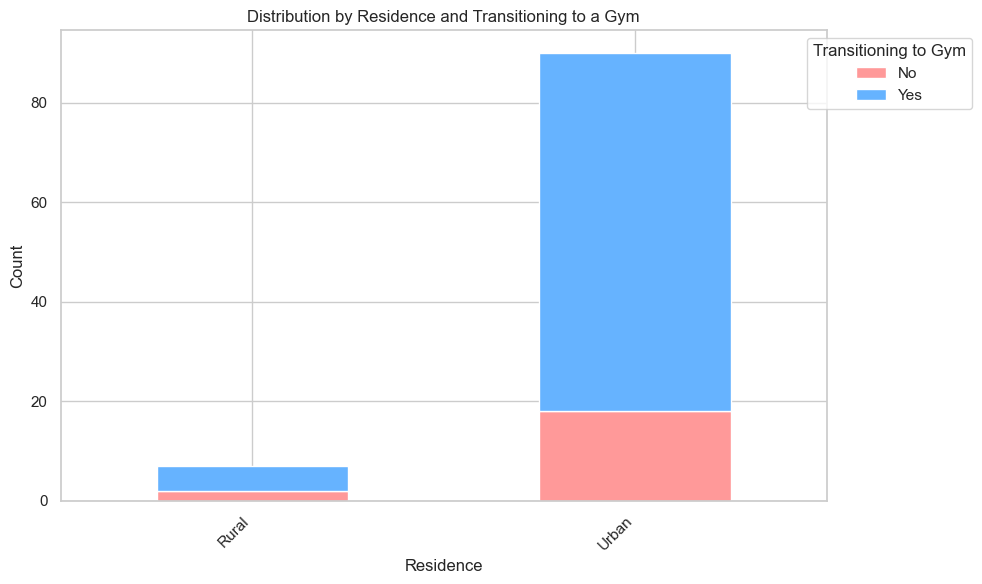

In [14]:
grouped_data = data.groupby(['Residence', 'Transitioning to a Gym'])['Residence'].count().unstack().fillna(0)
print(grouped_data)

colors = ['#ff9999', '#66b3ff']
ax = grouped_data.plot(kind='bar', stacked=True, color=colors, figsize=(10, 6))

ax.set_title('Distribution by Residence and Transitioning to a Gym')
ax.set_xlabel('Residence')
ax.set_ylabel('Count')

plt.xticks(rotation=45, ha='right')

ax.legend(title='Transitioning to Gym', loc='upper right', bbox_to_anchor=(1.2, 1))

plt.tight_layout()
plt.show()

## What solutions have respondents found to overcome their fitness challenges?

Solutions Found
Watching workout videos or tutorials                              55
Using fitness apps or programs                                    12
None, I don't actively seek solutions                             11
Online research and articles                                       8
No, I'm Not actively seeking a solution.                           5
Consulting with a fitness coach or trainer                         3
classpass                                                          1
working out with friends at home                                   1
Going to additional courses outside of home and physiotherapy      1
Name: count, dtype: int64


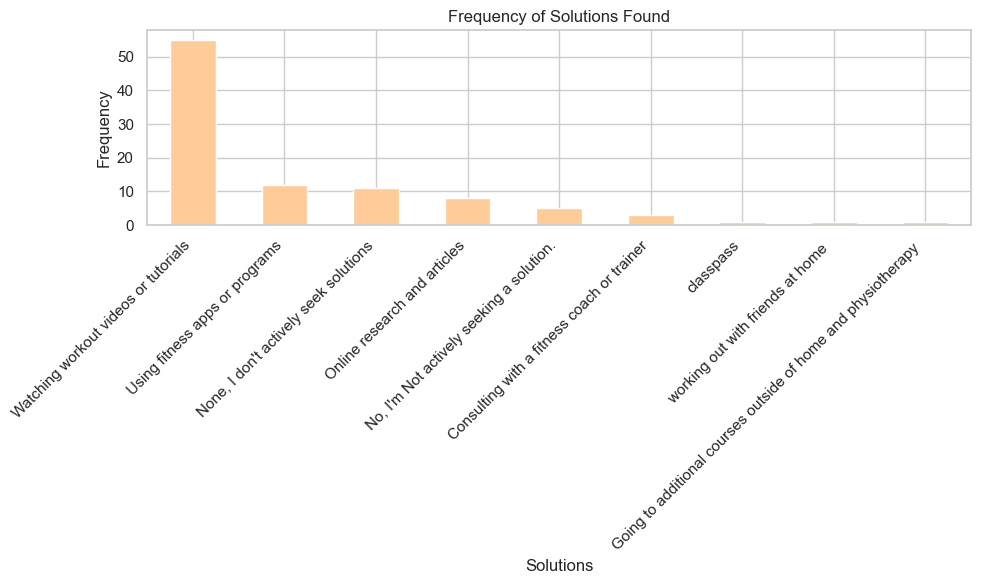

In [15]:
solution_counts = data["Solutions Found"].value_counts()
print(solution_counts)

solution_counts.plot(kind='bar', color='#ffcc99', figsize=(10, 6))

plt.title("Frequency of Solutions Found")
plt.xlabel("Solutions")
plt.ylabel("Frequency")

plt.xticks(rotation=45, ha='right')

plt.tight_layout()
plt.show()

## How is income distributed among participants, and what is the average income?

0         Under €20,000
1         Under €20,000
2         Under €20,000
3     €40,001 - €60,000
4         Under €20,000
            ...        
93        Over €100,000
94    €20,000 - €40,000
95    €40,001 - €60,000
96        Under €20,000
97    €20,000 - €40,000
Name: Approximate Annual Income Range in Euros (€), Length: 98, dtype: object


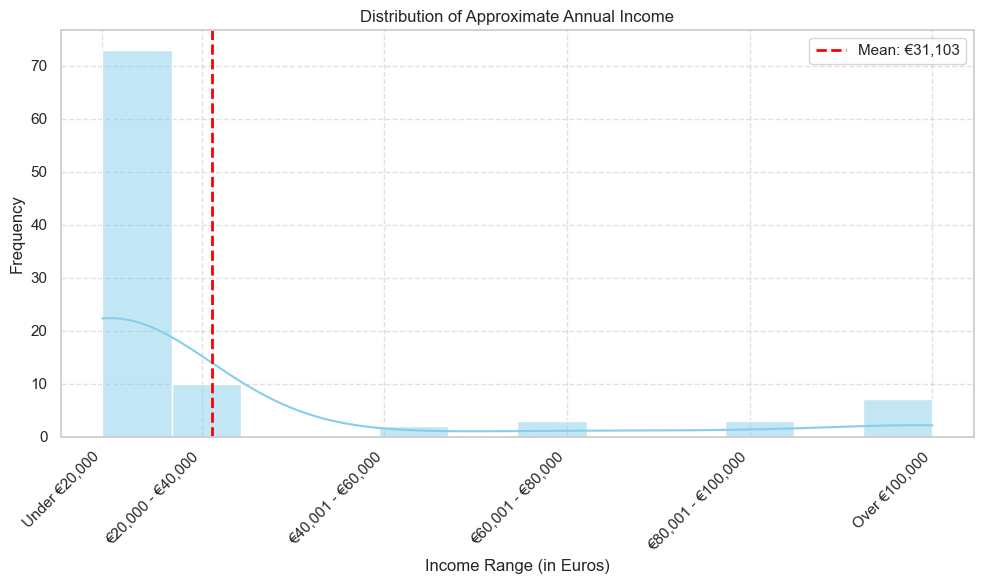

In [29]:
approximate_income = data["Approximate Annual Income Range in Euros (€)"]
print(approximate_income)

values = []

# Income mapping to numeric midpoints
income_mapping = {
    "Under €20,000": 19152,
    "€20,000 - €40,000": 30000,
    "€40,001 - €60,000": 50000,
    "€60,001 - €80,000": 70000,
    "€80,001 - €100,000": 90000,
    "Over €100,000": 110000,
}

# Convert to numeric values
for i in approximate_income:
    if pd.notna(i) and i in income_mapping:
        values.append(income_mapping[i])
    elif pd.notna(i) and "Under" in i:
        values.append(19152)
    elif pd.notna(i) and "Over" in i:
        values.append(110000)
    else:
        values.append(100000)  # Default fallback

# Calculate mean
mean_income = sum(values) / len(values)

# Plot
plt.figure(figsize=(10, 6))
sns.histplot(values, bins=12, kde=True, color='skyblue')

# Mean line
plt.axvline(mean_income, color='red', linestyle='--', linewidth=2, label=f'Mean: €{mean_income:,.0f}')
plt.legend()

# Title and labels
plt.title('Distribution of Approximate Annual Income')
plt.xlabel('Income Range (in Euros)')
plt.ylabel('Frequency')

# Custom tick positions and labels
tick_values = [19152, 30000, 50000, 70000, 90000, 110000]
tick_labels = [
    "Under €20,000",
    "€20,000 - €40,000",
    "€40,001 - €60,000",
    "€60,001 - €80,000",
    "€80,001 - €100,000",
    "Over €100,000"
]

plt.xticks(tick_values, tick_labels, rotation=45, ha='right')

# Grid and layout
plt.grid(True, linestyle='--', alpha=0.6)
plt.tight_layout()
plt.show()

## What is the distribution of gym proximity for urban residents?

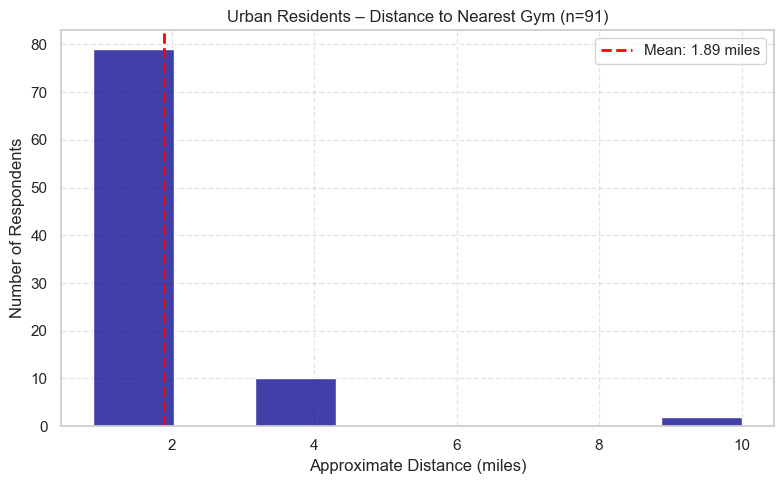

In [35]:
# Replace "I don't know" with NaN for clear analysis
data["Approximate Distance to the Nearest Gym"] = data["Approximate Distance to the Nearest Gym"].replace("I don't kNow", pd.NA)

# Filter urban respondents
urban_data = data[data["Residence"] == "Urban"]

# Extract numeric distances
urban_distances = (
    urban_data["Approximate Distance to the Nearest Gym"]
    .str.extract(r'([\d\.]+)')[0]
    .astype(float)
    .fillna(0)
    .replace({0: 0.9, 1: 1.5, 2: 3.5, 5: 8.0})
)

plt.figure(figsize=(8, 5))
sns.histplot(urban_distances, bins="auto", stat="count", color="darkblue")

# Calculate and plot mean
urban_mean = urban_distances.mean()
plt.axvline(urban_mean, color="red", linestyle="--", linewidth=2, label=f"Mean: {urban_mean:.2f} miles")

# Labels and title
plt.title(f"Urban Residents – Distance to Nearest Gym (n={len(urban_data)})")
plt.xlabel("Approximate Distance (miles)")
plt.ylabel("Number of Respondents")
plt.legend()

plt.tight_layout()
plt.grid(True, linestyle='--', alpha=0.5)
plt.show()

## What is the distribution of gym proximity for rural residents?

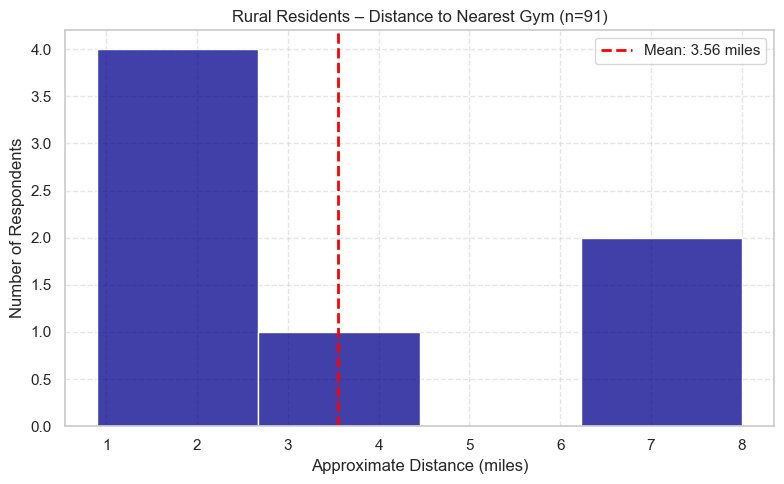

In [36]:
# Filter rural respondents
rural_data = data[data["Residence"] == "Rural"]

# Extract numeric distances
rural_distances = (
    rural_data["Approximate Distance to the Nearest Gym"]
    .str.extract(r'([\d\.]+)')[0]
    .astype(float)
    .fillna(0)
    .replace({0: 0.9, 1: 1.5, 2: 3.5, 5: 8.0})
)

plt.figure(figsize=(8, 5))
sns.histplot(rural_distances, bins="auto", stat="count", color="darkblue")

# Calculate and plot mean
rural_mean = rural_distances.mean()
plt.axvline(rural_mean, color="red", linestyle="--", linewidth=2, label=f"Mean: {rural_mean:.2f} miles")

# Labels and title
plt.title(f"Rural Residents – Distance to Nearest Gym (n={len(urban_data)})")
plt.xlabel("Approximate Distance (miles)")
plt.ylabel("Number of Respondents")
plt.legend()

plt.tight_layout()
plt.grid(True, linestyle='--', alpha=0.5)
plt.show()

## What is the distribution of the level of education of the respondents?

Level of Education
Bachelor's degree                      62
High School or below                   17
Some college or vocational training    11
Master's degree                         5
Doctorate or other advanced degree      3
Name: count, dtype: int64


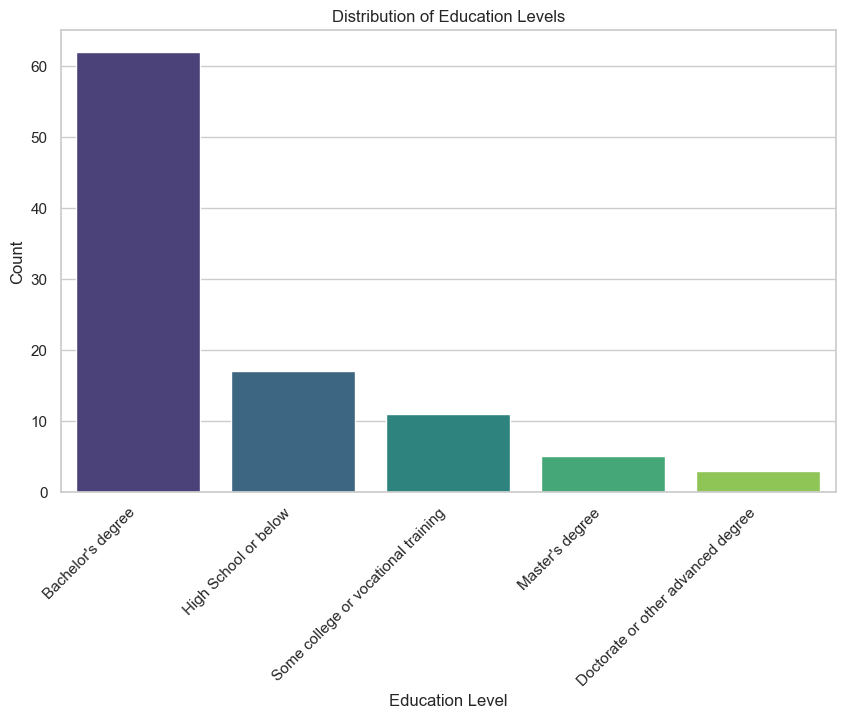

In [40]:
education_counts = data["Level of Education"].value_counts()
print(education_counts)

plt.figure(figsize=(10, 6))
sns.set(style="whitegrid")
ax = sns.barplot(x=education_counts.index, y=education_counts.values, hue=education_counts.index, palette="viridis", legend=False)

ax.set(xlabel="Education Level", ylabel="Count")
ax.set_title("Distribution of Education Levels")
plt.xticks(rotation=45, ha="right")

plt.show()

## How does the average number of home workouts per week vary across different age and income groups?

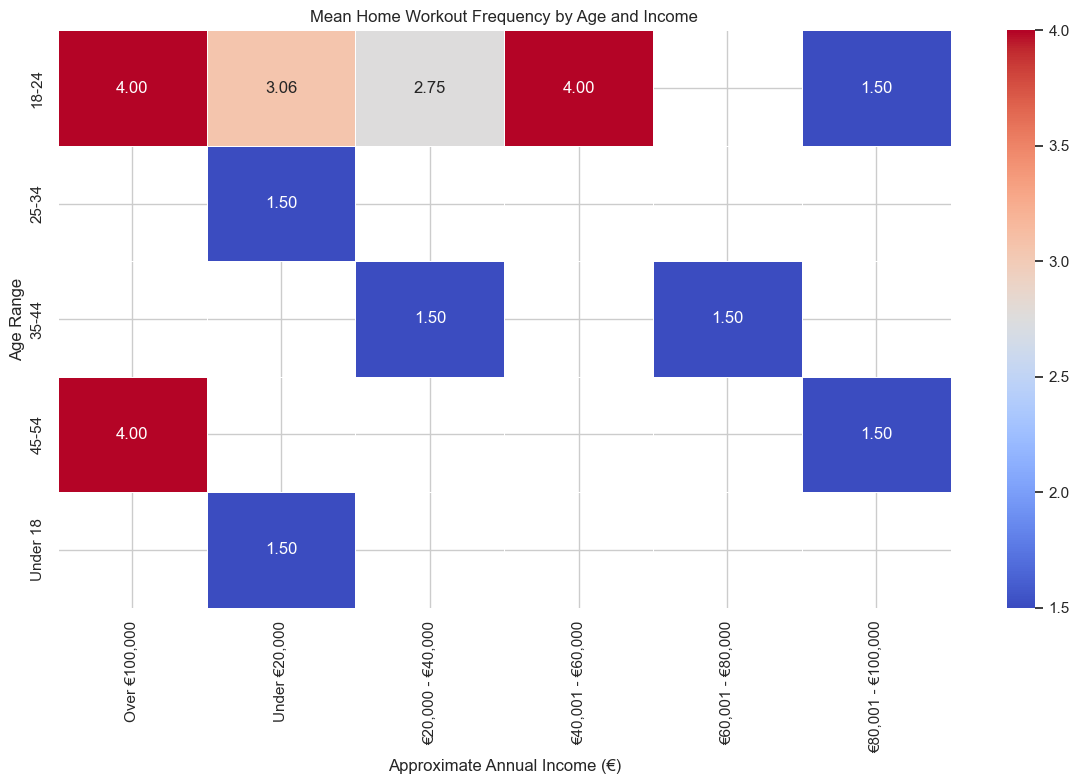

In [43]:
# Step 1: Map frequency text responses to numeric values
frequency_map = {
    "Daily": 7,
    "3-5 times per week": 4,
    "1-2 times per week": 1.5,
    "Less than once a week": 0.5,
}

# Apply the mapping to a new column
data["Numeric Workout Frequency"] = data["Frequency of Workouts at Home"].map(frequency_map)

# Step 2: Group by Age Range and Income Range, then calculate mean frequency
means = data.groupby(
    ["Age Range", "Approximate Annual Income Range in Euros (€)"]
)["Numeric Workout Frequency"].mean().reset_index()

# Step 3: Pivot the data for heatmap plotting
pivot_table = means.pivot_table(
    index="Age Range",
    columns="Approximate Annual Income Range in Euros (€)",
    values="Numeric Workout Frequency"
)

# Step 4: Plot the heatmap
plt.figure(figsize=(12, 8))
sns.heatmap(
    pivot_table,
    annot=True,            # Show numeric values
    fmt=".2f",             # Format numbers with 2 decimals
    cmap="coolwarm",       # Color palette
    cbar=True,             # Show color bar
    linewidths=0.5         # Add lines between cells
)

plt.title("Mean Home Workout Frequency by Age and Income")
plt.xlabel("Approximate Annual Income (€)")
plt.ylabel("Age Range")
plt.tight_layout()
plt.show()


## How does the frequency of home workouts differ between rural and urban residents?

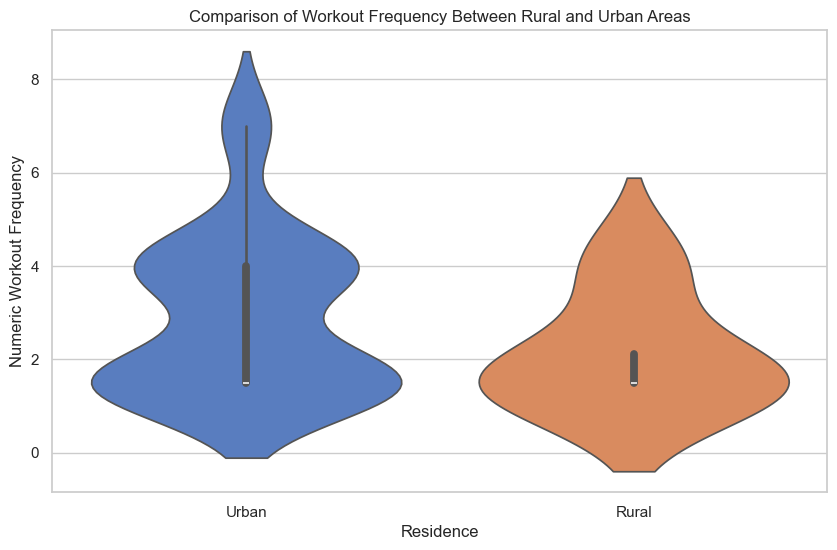

In [52]:
plt.figure(figsize=(10, 6))

sns.violinplot(x="Residence", y="Numeric Workout Frequency", data=data, palette="muted", hue="Residence", legend=False, inner="box") # quartile, stick, None

plt.xlabel("Residence")
plt.ylabel("Numeric Workout Frequency")
plt.title("Comparison of Workout Frequency Between Rural and Urban Areas")

plt.show()

## How do age and income relate to the frequency of home workouts?

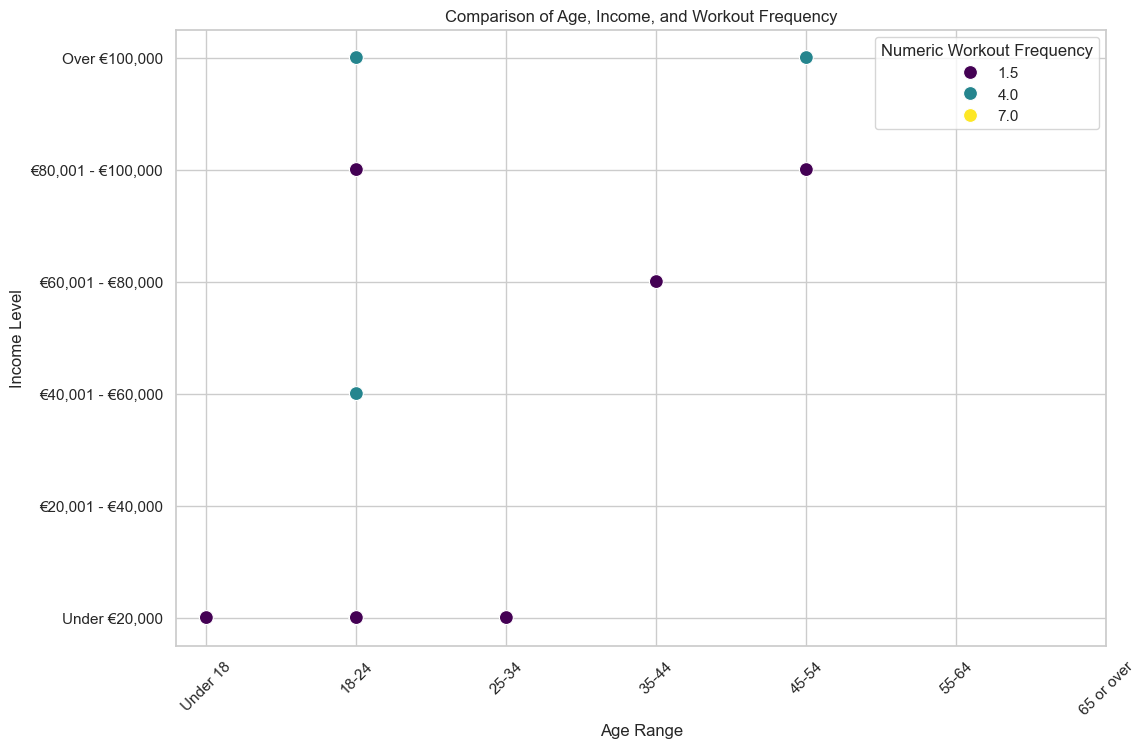

In [45]:
income_mapping = {
    "Under €20,000": 1,
    "€20,001 - €40,000": 2,
    "€40,001 - €60,000": 3,
    "€60,001 - €80,000": 4,
    "€80,001 - €100,000": 5,
    "Over €100,000": 6,
}

age_order = ["Under 18", "18-24", "25-34", "35-44", "45-54", "55-64", "65 or over"]
age_mapping = {age: i + 1 for i, age in enumerate(age_order)}

data["Income Level"] = data["Approximate Annual Income Range in Euros (€)"].map(income_mapping)
data["Age Order"] = data["Age Range"].map(age_mapping)

data.loc[data["Frequency of Workouts at Home"] == "0.5 times per week", "Numeric Workout Frequency"] = 0.5

plt.figure(figsize=(12, 8))

sns.scatterplot(
    x="Age Order",
    y="Income Level",
    hue="Numeric Workout Frequency",
    data=data,
    palette="viridis",
    s=100,
)

plt.legend(title="Numeric Workout Frequency", title_fontsize="12")

plt.xlabel("Age Range")
plt.ylabel("Income Level")
plt.title("Comparison of Age, Income, and Workout Frequency")

plt.yticks(list(income_mapping.values()), income_mapping.keys())
plt.xticks(list(age_mapping.values()), age_order, rotation=45)

plt.show()